# ROMMA Scraping again

Almost everyone knows that you can get time series by scraping pages.


https://www.infoclimat.fr/climatologie/normales-records/1981-2010/grenoble-lvd/valeurs/38538002.html

http://romma.fr/station_24.php?id=4&tempe=1

## Correlation between altitude and temperature

I actually did this after looking at the local data (see below).
The main problem was to get the correct page served. The data
is "hidden" behind a request like this

```/carte.php?dept=0&param=temperature&mobile=0&carteinterne=0```

but I kept getting a 403 error
when I asked for it using **get**. The problem was that I 
didn't set the User-Agent string correctly. After I copied 
it over from Chrome everything was easy.



## Local data

So I ended up doing averaging the data and doing some linear regression - 
all the variables:

- temperature
- humidity 
- solar radiation
- windiness

seem to be correlated.


In [1]:

# one of the package managers uv or pip or conda has f*cked up my PATH\n",
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")
 

import matplotlib.pyplot as plt
import numpy as np 
import re
import time

import requests
import html

from scipy import stats

/tmp/ipykernel_20893/1713490962.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy import stats


In [72]:
1/slope

np.float64(-258.2628159725918)

## Extracting the data arrays

The good stuff is hiden in a frame but is easily accesible

In [6]:
import re
import numpy as np

def html2arrays(txt):
    """
    Parses JavaScript arrays from raw ROMMA HTML data, converts them 
    to NumPy arrays, and aligns missing data to a fixed 10-minute grid.
    """
    # Replace JSON-style nulls with string nans for easier float conversion
    txt = re.sub(r'null', 'nan', txt)

    # Regex to capture variable names and their array contents inside brackets
    pattern = re.compile(r'var\s+([\w\s]*?)array\s*=\s*.*?\[(.*?)\]', re.DOTALL)
    data = dict(pattern.findall(txt))

    fields = ['time', 'temp', 'pluie', 'intenspluie', 'pression', 
              'hum', 'rad', 'rafale', 'vent', 'ventdir']
    
    arrays = {}
    index = None  # Initialize grid index variable

    for key in fields:     
        if key not in data:
            print(f"Warning: Key '{key}' not found in scraped data.")
            continue
            
        try:
            # Safely split strings and convert to float/NaN
            raw_vals = data[key].split(',')
            parsed_vals = [float(x) if x.strip() != '' else float('nan') for x in raw_vals]
            arrays[key] = np.array(parsed_vals)
            
            # Time synchronization and hole-fixing pipeline
            if key == 'time':
                # Convert timestamps to 10-minute grid indices (600,000 ms)
                index = (arrays['time'] - arrays['time'][0]) / 600000  
                index = index.astype(np.int32)
                index = np.clip(index, 0, 4463)  # Safe bounding to max array size
            
            elif index is not None:
                # Map irregular time series data onto a fixed-size baseline array
                fixed_grid = np.zeros(4464)
                fixed_grid[index] = arrays[key]
                arrays[key] = fixed_grid
                
        except Exception as e:
            print(f"Error processing field '{key}': {e}")
            
    return arrays
    
def get_station(ref_num=6):       
    base_url = 'https://www.romma.fr'
    url = base_url + '/frame_station24.php?id_station={}&tempe=1&humi=&pluie=&vent=&pressure=&rayonnement=&neige='

    headers = {'User-Agent': "Mozilla/5.0 (X11; CrOS x86_64 13099.62.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/84.0.4147.83 Safari/537.36",
             'Host': 'romma.fr',
            'Referer': 'https://www.romma.fr/station_24.php?id=4&tempe=1'}
    
    print(f'Fetching station {ref_num}')
    
    r = requests.post(url.format(ref_num) , 
                     headers=headers)
    
    return r.text


data = {}
for k in [1,3,5,44,4,552]: 
    tt = get_station(ref_num=k)
    meteo = html2arrays(tt)
    data[k] = meteo


Fetching station 1
Fetching station 3
Fetching station 5
Fetching station 44
Fetching station 4
Fetching station 552


I think this is a request in Chrome developper capture to get the User-Agent

In [27]:
GET /frame_station24.php?id_station=4&tempe=1&humi=&pluie=&vent=&pressure=&rayonnement=&neige= HTTP/1.1
Host: www.romma.fr
Connection: keep-alive
Upgrade-Insecure-Requests: 1
DNT: 1
User-Agent: Mozilla/5.0 (X11; CrOS x86_64 13505.27.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/87.0.4280.38 Safari/537.36
Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9
Sec-Fetch-Site: same-origin
Sec-Fetch-Mode: navigate
Sec-Fetch-Dest: iframe
Referer: https://www.romma.fr/station_24.php?id=4&tempe=1
Accept-Encoding: gzip, deflate, br
Accept-Language: en-IE,en;q=0.9,fr-FR;q=0.8,fr;q=0.7,zh-CN;q=0.6,zh;q=0.5,en-US;q=0.4,nl;q=0.3
Cookie: rid=51Yg44; paramtab=0; ui-tabs-1=1


b'<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">\n<html><head>\n<title>404 Not Found</title>\n</head><body>\n<h1>Not Found</h1>\n<p>The requested URL was not found on this server.</p>\n<hr>\n<address>Apache/2.4.38 (Debian) Server at romma.fr Port 443</address>\n</body></html>\n'

Vizille = 5 seemed to be out of sync with the other sites

In [7]:
for k in [3,5,44,4,552]: 
    print(data[k]['time'][0])

1776843000000.0
1776843000000.0
1776843000000.0
1776843000000.0
1776843000000.0


In [5]:
(1592553600000.0 - 1592546400000.0) / 60000

120.0

In [9]:
from datetime import datetime, timezone
import pickle
import numpy as np

def generate_filename(timestamp_ms):
    """
    Generates a localized filename based on the timestamp.
    Example: 1767097200000 (Dec 30) -> '30_dec.pkl'
    """
    dt = datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)
    
    # French locale abbreviations match your format ('dec', 'jan', etc.)
    # .strftime('%b') gives short month name (e.g., 'Dec'), we lowercase it
    month_str = dt.strftime('%b').lower()
    day_str = dt.strftime('%d')
    
    # Strip leading zero from day if desired (e.g., '05_dec' -> '5_dec')
    day_str = str(int(day_str)) 
    
    return f"{day_str}_{month_str}.pkl"

def extract_decimal_hours(timestamps):
    """
    Converts a NumPy array of millisecond timestamps into decimal hours.
    """
    dt_objects = [datetime.fromtimestamp(ts / 1000, tz=timezone.utc) for ts in timestamps]
    hours = np.array([dt.hour for dt in dt_objects])
    minutes = np.array([dt.minute for dt in dt_objects])
    return hours + (minutes / 60.0)

# Define a standard day length in terms of 10-minute intervals
DAY_INTERVALS = 24 * 6

# Extract timestamps safely
available_timestamps = data[4]['time']
actual_day_timestamps = available_timestamps[:min(DAY_INTERVALS, len(available_timestamps))]

# Vectorized computation of decimal hours
data['times'] = extract_decimal_hours(actual_day_timestamps)

# --- Dynamic Filename Resolution ---
# Automatically determine filename from the first timestamp in the data
try:
    first_timestamp = available_timestamps[0]
    output_filename = generate_filename(first_timestamp)
except (IndexError, KeyError, TypeError):
    # Fallback if the time array is empty or structurally broken
    output_filename = 'fallback_backup.pkl'

# Serialization
try:
    with open(output_filename, 'wb') as fp:
        pickle.dump(data, fp)
    print(f"Successfully serialized data to dynamic destination: {output_filename}")
except Exception as e:
    print(f"Serialization failed: {e}")

Successfully serialized data to dynamic destination: 22_apr.pkl


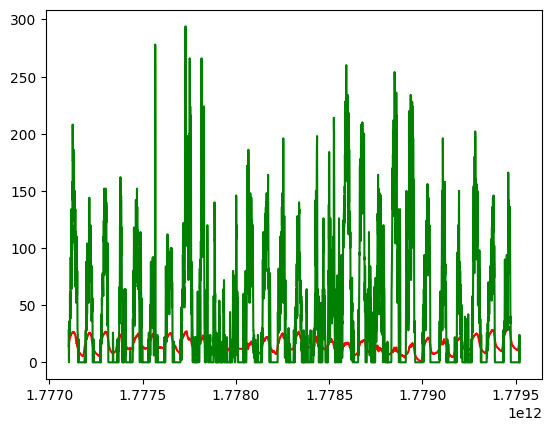

In [16]:
meteo = data[5]

ww = 28*24*6

plt.plot(meteo['time'][-ww:], meteo['temp'][-ww:],'r')
plt.plot( meteo['time'][-ww:], meteo['vent'][-ww:]*20,'g')

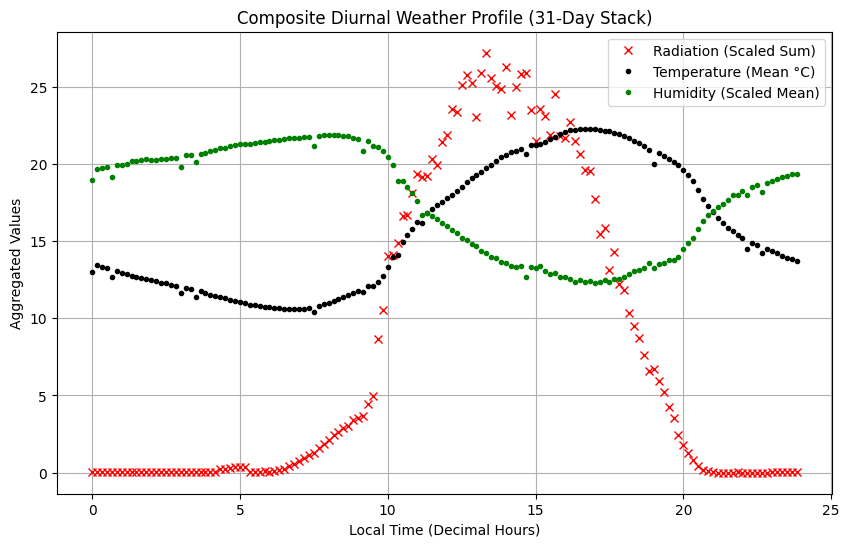

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import zoneinfo

# --- Setup Constants ---
INTERVALS_PER_DAY = 24 * 6  # 144 points
TOTAL_DAYS = 31
EXPECTED_SIZE = TOTAL_DAYS * INTERVALS_PER_DAY  # 4464 points

meteo = data[4]
local_tz = zoneinfo.ZoneInfo("Europe/Paris")

# --- 1. Compute Time Axis (Decimal Hours) Safely ---
timestamps_day1 = meteo['time'][:INTERVALS_PER_DAY]
dt_objects = [datetime.fromtimestamp(ts / 1000, tz=local_tz) for ts in timestamps_day1]
times = np.array([dt.hour + dt.minute / 60.0 for dt in dt_objects])


# --- 2. Vectorized Daily Averaging Function using Reshape ---
def get_daily_mean(key):
    """
    Reshapes flat weather data into a (Days, Intervals) matrix 
    and returns a 24-hour mean profile across the entire month.
    """
    raw_array = meteo[key][:EXPECTED_SIZE]
    grid = raw_array.reshape(TOTAL_DAYS, INTERVALS_PER_DAY)
    
    # Collapse along rows (axis=0) to get the average for each 10-minute slot
    return np.nanmean(grid, axis=0)


# --- 3. Compute True Daily Means ---
mean_rad  = get_daily_mean('rad')
mean_temp = get_daily_mean('temp')
mean_hum  = get_daily_mean('hum')


# --- 4. Plotting Pipeline (Object-Oriented API) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data layers on the explicit axes object
ax.plot(times, tot_rad / 25.0, 'rx', label='Radiation (Scaled Sum)')
ax.plot(times, tot_temp,        'k.', label='Temperature (Mean °C)')
ax.plot(times, tot_hum / 4.0,   'g.', label='Humidity (Scaled Mean)')

# Labeling and styling using the ax interface
ax.set_xlabel('Local Time (Decimal Hours)')
ax.set_ylabel('Aggregated Values')
ax.set_title('Composite Diurnal Weather Profile (31-Day Stack)')
ax.legend()
ax.grid(True)

# Display the clean figure
plt.show()

It is incredibly satisfying when the raw physics pops right out of a clean dataset! What your student is looking at on that plot are two fundamental thermodynamic mechanisms playing out across the valley floor.

### 1. Thermal Inertia (The Radiation-Temperature Lag)

The lag between peak solar radiation and peak temperature is a classic demonstration of **thermal mass and heat transfer**.

The atmosphere doesn’t actually get heated directly by incoming shortwave solar radiation. Instead, the sun heats the earth's surface (the valley floor and the surrounding rock walls of Belledonne and Chartreuse). The ground absorbs this energy, warms up, and then heats the adjacent air via conduction and longwave thermal radiation.

This process takes time. Solar radiation peaks precisely when the sun is at its highest astronomical point (around 1:30 PM local summer time in France), but the ground and air continue to accumulate net heat for a few hours after that peak, causing the temperature to crest later in the afternoon.

```
[ Solar Noon: Radiation Peaks ] 
               │
               ▼ (Energy absorbed by valley floor)
       [ Conduction & Ground Radiative Heating ]
               │
               ▼ (Delay / Phase Lag)
[ ~2 Hours Later: Air Temperature Peaks ]

```

### 2. The Temperature-Humidity Inverse Correlation

The tight, mirror-image inverse relationship between temperature and humidity isn't actually because the air is losing water during the day; it's a consequence of how **Relative Humidity (RH)** is calculated.

Relative humidity is a ratio: how much water vapor is *actually* in the air versus the maximum amount of water vapor the air *could* hold at that specific temperature.

$$\text{RH} = \frac{\text{Actual Water Vapor (Absolute Humidity)}}{\text{Maximum Water Vapor Capacity}}$$

Because warmer air expands and its capacity to hold water vapor increases exponentially (governed by the **Clausius-Clapeyron equation**), the denominator in that equation skyrockets as the afternoon heats up. Even if the absolute amount of water vapor in the valley stays exactly the same, the *relative* humidity plummets, creating that beautiful mirror-image curve on the student's plot.

### A Great Next Step for the Student

If your student wants to prove that the water content itself isn't dropping out of the air during the day, they can use the temperature and humidity arrays to calculate the **Dew Point** or **Absolute Humidity**.

If they plot *that* metric against the time axis, they should see a relatively flat line across the 24-hour cycle—proving that while the *relative* humidity mirrors temperature perfectly, the actual moisture mass in the valley remains steady!

# There must be a better way

the function tot() kind of sucks  
- it's not very **numpy**.

what we really need is to 

1. reshape so that a row represents a day 
1. sum over the columns to get the average.

In [20]:
np.arange(12).reshape(3,4), np.sum(np.arange(12).reshape(3,4), axis=0)

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([12, 15, 18, 21]))

In [24]:
len(data[3]['temp'])

4464

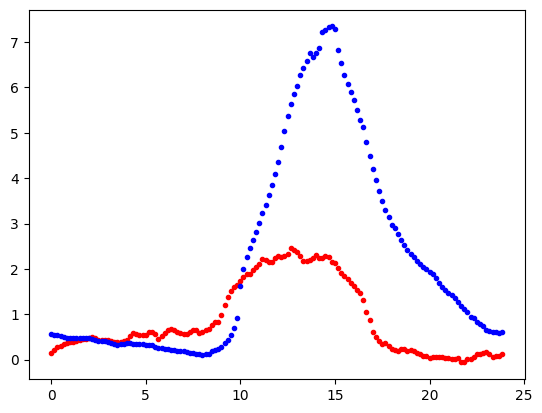

In [22]:
npts = 4464
ndays = npts//24//6

cols = [ x for x in 'rbgky']

# 6 is corrupted so it didn't load
for k in [3,5]:
    mm = data[k]['temp'].reshape(ndays, 24*6)/ndays
    #clean up the nan
    mm[np.isnan(mm)] = 0
    mm[mm>1000] = 0
    plt.plot(times, np.sum(mm, axis=0), cols.pop(0) + '.')

In [26]:
npts = 4464
ndays = npts//24//6

blacklist = ['time', 'pression', 
             'ventdir', 'pluie', 
             'intenspluie']

averages = {}

for station, series in data.items():
    #I stored the times as a field it's an ndarray not dict
    if station == 'times': continue
    tmp = {}
    for tag, xx in series.items():
        if tag in blacklist: continue
        mm = xx.reshape(ndays, 24*6)/ndays
        #clean up the nan
        mm[np.isnan(mm)] = 0
        #kill outliers in rad
        mm[mm>1000] = 0
        tmp[tag] = np.sum(mm, axis=0)
    averages[station] = tmp
     

## Let's show them all in a multiplot

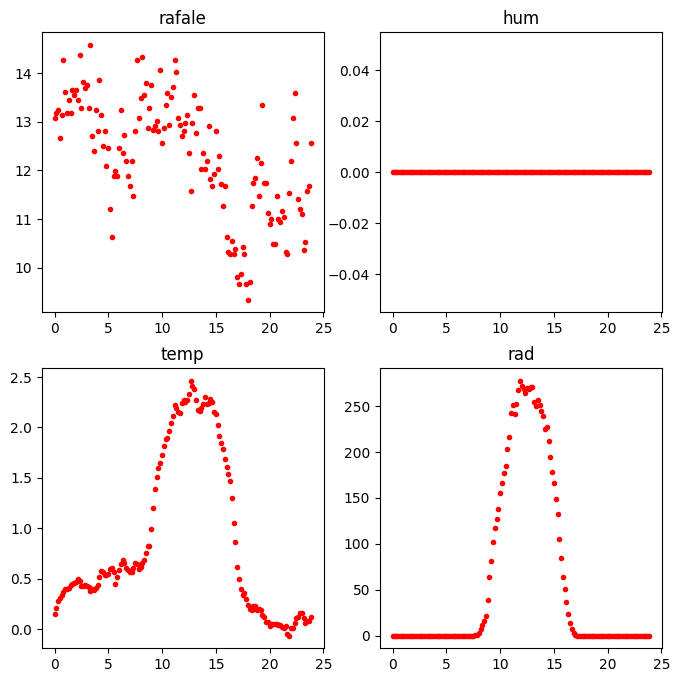

In [28]:
fig, axs = plt.subplots(2,2)
#[axi.set_axis_off() for axi in axs.ravel()]
fig.set_size_inches(8,8)

meteo = averages[3]

for k,tag in enumerate(['rafale','temp','hum','rad']):

    axs[k % 2 , k // 2].plot(times, meteo[tag],'r.')
    axs[k % 2 , k // 2].set_title(tag)
    

# Sunshine over a month

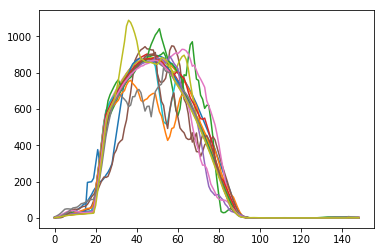

In [184]:
xx = np.copy(data[4]['rad'])
xx[xx > 2000] = 1000
xx = xx.reshape(31, len(xx)//31 )

for x in xx:
    if sum(x) < 35000: continue
    plt.plot(np.convolve(x,np.ones(6))/6 )

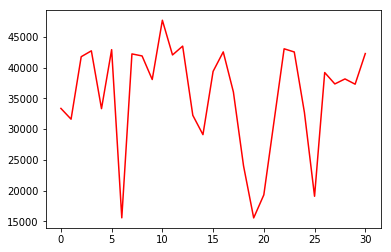

In [191]:
plt.plot([sum(x) for x in xx],'r-')

## Humidity and temperature

they seem to be correlated so let's do a linear regression to see if that is actually the case.

There might be **nan**s in the arrays so mask them out before doing the regression.

In [192]:
from scipy import stats

cors = {}
for k in [3,4,5,6,109]:
    x = data[k]
    X = np.sum( x['temp'].reshape(ndays, 24*6)/ndays, axis=0)
    Y = np.sum( x['hum'].reshape(ndays, 24*6)/ndays, axis=0)

    mask = ~(np.isnan(X) | np.isnan(Y))
    cors[k] = stats.linregress( X[mask], Y[mask])

In [193]:
cors

{3: LinregressResult(slope=-0.19110208104744422, intercept=77.13673974184037, rvalue=-0.21444092960366498, pvalue=0.010116405778747018, stderr=0.0733036838367571),
 4: LinregressResult(slope=-3.0097099747342506, intercept=130.54678025904084, rvalue=-0.9973370898886585, pvalue=2.2831382853717435e-163, stderr=0.01846896005041522),
 5: LinregressResult(slope=-3.028282245204879, intercept=134.84021286633964, rvalue=-0.993976627063515, pvalue=2.9947835834283367e-138, stderr=0.028019211801428624),
 6: LinregressResult(slope=-3.3110073718837683, intercept=137.2393557999482, rvalue=-0.9969033456491834, pvalue=1.0117975331182666e-158, stderr=0.021917338258521518),
 109: LinregressResult(slope=-2.7249459297370366, intercept=121.19107074344143, rvalue=-0.9779881901843425, pvalue=3.6240069850456903e-97, stderr=0.04913602090582902)}

### Retiming

I have to plot the data against time otherwise it's offset
so that midnight is no longer at zero.

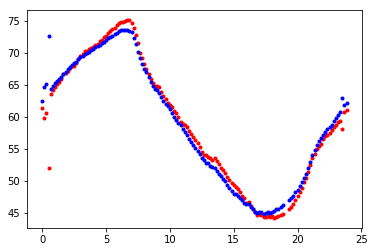

In [225]:
k = 109

vv = cors[k]
a, b = vv.slope, vv.intercept

x = data[k]
X = np.sum( x['temp'].reshape(ndays, 24*6)/ndays, axis=0)
Y = np.sum( x['hum'].reshape(ndays, 24*6)/ndays, axis=0)

plt.plot(times,Y,'r.')
#plt.plot(times,X,'g.')
plt.plot(times, a*X + b, 'b.')

## Finally calculate the time of max temperature

I checked this by hand it seems to be pretty accurate
but there is a bug with multiple days

In [33]:
time_tics = data[3]['time']

TS = data[4]['temp']

numdays = 30
ts = [i for i in range(-1,-1 - numdays*24*6, -24*6)]

#use smh as a reference the others don't seem reliable
day_intervals = [list(zip( TS, time_tics))[i:j] 
                                       for i,j in  zip(ts[1:],ts)]
mx = [max(day) for day in day_intervals if day]
x,y = zip(*mx)
[time.ctime(t/1000.)[4:16] for t in y]

['Dec  1 16:00',
 'Nov 30 15:50',
 'Nov 29 15:10',
 'Nov 28 14:40',
 'Nov 27 16:00',
 'Nov 26 15:20',
 'Nov 25 14:20',
 'Nov 25 10:40',
 'Nov 24 04:10',
 'Nov 22 15:40',
 'Nov 21 19:30',
 'Nov 20 12:00',
 'Nov 20 01:30',
 'Nov 18 14:30',
 'Nov 17 15:00',
 'Nov 16 15:30',
 'Nov 15 15:50',
 'Nov 14 15:20',
 'Nov 13 12:50',
 'Nov 12 15:30',
 'Nov 11 14:50',
 'Nov 10 15:30',
 'Nov  9 15:10',
 'Nov  8 15:40',
 'Nov  7 14:40',
 'Nov  6 14:40',
 'Nov  5 15:50',
 'Nov  4 15:50',
 'Nov  3 15:30']

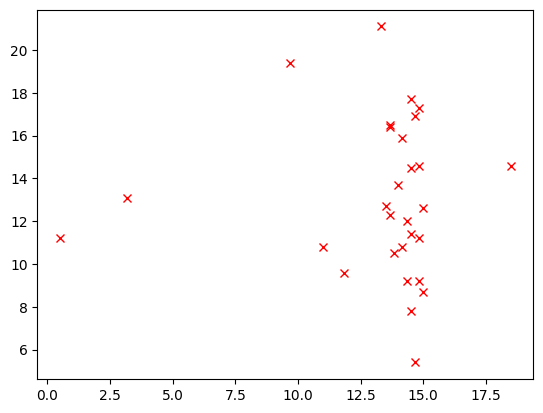

In [35]:
XS, YS = zip(*mx)
YS = [(int(y)//1000 % (24*3600)) /3600 for y in YS]
plt.plot(YS,XS, 'rx');

In [43]:
len(data[4]['temp'])

31

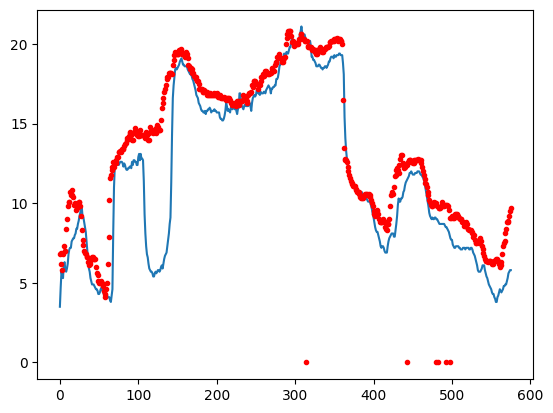

In [49]:
len_day = 6*24

plt.plot(data[4]['temp'][-len_day*9:-len_day*5])
plt.plot(data[552]['temp'][-len_day*9:-len_day*5],'r.');

## Calculate the length of a day

In [209]:
for k, y in averages.items():
    if max(y['rad']) == 0: continue
    day_light = times[y['rad'] > 4]
    print(k, max(day_light), min(day_light) )

3 21.333333333333332 6.0
5 21.333333333333332 6.166666666666667
109 21.166666666666668 6.0
4 21.333333333333332 6.166666666666667
6 21.333333333333332 6.166666666666667


In [208]:
min(averages[44]['rad'])

0.0

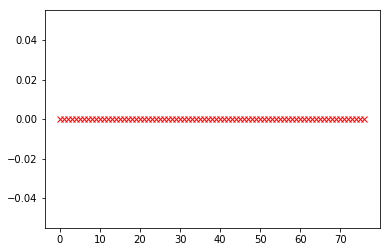

In [126]:
trans = [int(y)//1000 % (24*3600) /3600 for y in night]
trans = [ min(x,8) for x in trans ]

plt.plot(range(len(trans)),trans,'rx')

In [516]:
! ./.g


[master 300c919] web
 2 files changed, 165 insertions(+), 101 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 30.53 KiB | 976.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   991f4c4..300c919  master -> master


In [111]:
4464 - 4455

9

In [115]:
tt = get_station(ref_num=109)
meteo = html2arrays(tt)
len(meteo['time'])

4455

In [135]:
index = (meteo['time'] - meteo['time'][0])/600000 
index = index.astype(np.int32)

In [139]:
uu = np.diff(index)
sum( uu[uu > min(uu)] - min(uu) )

9

In [128]:
4464 // 24 //6

31

In [188]:
! ./.g

[master e64405b] web
 2 files changed, 18 insertions(+), 18 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 484 bytes | 121.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   a388f89..e64405b  master -> master


In [57]:
! ./.g



[master b8c191e] web
 5 files changed, 9961 insertions(+), 23 deletions(-)
 create mode 100644 romma_2026_05_22_19-30.html
 create mode 100644 romma_2026_05_22_19-30.png
 create mode 100644 romma_2026_05_22_20-13.html
 create mode 100644 romma_2026_05_22_20-13.png
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 301.91 KiB | 2.40 MiB/s, done.
Total 7 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   2026ae6..b8c191e  master -> master
